# 🥇 도장 3: 카드 게임 AI — Q-Table도 바꿔야 한다!

**난이도**: 🥇 어려움 (40-50분)

**핵심 메시지**: 상태가 숫자가 아니라 **튜플**이면? `np.zeros` Q-Table이 안 됩니다! **자료구조를 바꿔야 합니다.**

**Blackjack-v1 환경**:
- 상태: `(player_sum, dealer_card, usable_ace)` 튜플
- 2개 행동: stick (멈추기), hit (카드 더 받기)
- 21에 가까우면 이기고, 넘으면 버스트!

---

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 윈도우용 한글 폰트 설정 (맑은 고딕 예시)
plt.rcParams["font.family"] = "Malgun Gothic"

# 2. 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 만약 나눔고딕을 꼭 쓰고 싶다면, 윈도우에 나눔고딕 폰트파일(.ttf)을 
# 직접 설치한 후 아래와 같이 이름을 지정하면 됩니다.
# plt.rcParams["font.family"] = "NanumGothic"

print("한글 폰트 설정 완료 (Windows)")


한글 폰트 설정 완료 (Windows)


## 셀 1 — 라이브러리 임포트

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

print('라이브러리 임포트 완료!')

라이브러리 임포트 완료!


## 셀 2 — 환경 탐색: 상태가 튜플이다!

지금까지 FrozenLake, Taxi, CliffWalking은 상태가 **정수**였습니다.

Blackjack은 상태가 **튜플**입니다. 이게 무엇을 의미하는지 확인해봅시다.

In [4]:
import gymnasium as gym

# 블랙잭 환경 생성
env = gym.make('Blackjack-v1', sab=True) # Blackjack-v1, sab=True: 스탠다드 규칙

# 환경 초기화
state, info = env.reset()

# 상태 확인 — 정수가 아니라 튜플!
print(f'초기 상태: {state} (타입: {type(state)})')

초기 상태: (21, 5, 1) (타입: <class 'tuple'>)


## 셀 3 — 왜 np.zeros Q-Table이 안 되나?

FrozenLake/Taxi/CliffWalking은 상태가 정수라서 `np.zeros((상태수, 행동수))`로 Q-Table을 만들었습니다.

Blackjack은 상태가 **(15, 10, False)** 같은 튜플이라서 인덱스로 쓸 수 없습니다!

In [5]:
# 문제 상황: 상태가 정수가 아니라서 np.zeros로 인덱싱 불가
print('=== 왜 np.zeros가 안 되나? ===')
print()
print('FrozenLake: state = 7 (정수) → q_table[7] 가능!')
print('Blackjack:  state = (15, 10, False) (튜플) → q_table[(15, 10, False)] 불가!')
print()

# 이론적으로 배열로 만들 수 있지만...
# player_sum: 4~21 (18가지), dealer_card: 1~10 (10가지), usable_ace: True/False (2가지)
# → 18 * 10 * 2 = 360 상태... 하지만 실제로는 일부만 방문됨
print('이론적 상태 수: 18 * 10 * 2 = 360')
print('하지만 실제로 방문하는 상태는 훨씬 적음!')
print()
print('해결책: 딕셔너리(defaultdict) 사용!')
print('  → 방문한 상태만 저장, 메모리 효율적')
print('  → 튜플을 키로 사용 가능')

=== 왜 np.zeros가 안 되나? ===

FrozenLake: state = 7 (정수) → q_table[7] 가능!
Blackjack:  state = (15, 10, False) (튜플) → q_table[(15, 10, False)] 불가!

이론적 상태 수: 18 * 10 * 2 = 360
하지만 실제로 방문하는 상태는 훨씬 적음!

해결책: 딕셔너리(defaultdict) 사용!
  → 방문한 상태만 저장, 메모리 효율적
  → 튜플을 키로 사용 가능


## 셀 4 — defaultdict 기반 Q-Table

`np.zeros` 대신 `defaultdict`를 사용합니다. 처음 보는 상태도 자동으로 `[0, 0]`을 생성합니다!

In [6]:
from collections import defaultdict
import numpy as np

# defaultdict 기반 Q-Table
q_table = defaultdict(lambda: np.zeros(2))  # defaultdict, 행동 수 = 2

# 사용법 확인
test_state = (15, 10, False)
print(f'처음 보는 상태 {test_state}:')
print(f'  q_table[{test_state}] = {q_table[test_state]}')  # [0.0, 0.0] 자동 생성!
print()

# np.zeros Q-Table처럼 사용 가능
print('사용법 비교:')
print('  np.zeros:    q_table[state][action]     ← state가 정수일 때')
print('  defaultdict: q_table[state][action]     ← state가 튜플이어도 OK!')
print()

# argmax도 동일하게 사용
print(f'  np.argmax(q_table[{test_state}]) = {np.argmax(q_table[test_state])}')

처음 보는 상태 (15, 10, False):
  q_table[(15, 10, False)] = [0. 0.]

사용법 비교:
  np.zeros:    q_table[state][action]     ← state가 정수일 때
  defaultdict: q_table[state][action]     ← state가 튜플이어도 OK!

  np.argmax(q_table[(15, 10, False)]) = 0


## 셀 5 — Blackjack용 epsilon_greedy 함수

state가 튜플이어도 동일하게 작동합니다. 행동이 2개(0: stick, 1: hit)인 것만 다릅니다.

In [7]:
import numpy as np
import random

def epsilon_greedy_bj(state, q_table, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()  # 탐험 (랜덤 행동)
    else:
        return np.argmax(q_table[state])  # 활용 (최적 행동)


# 테스트
test_state = (15, 10, False)
# q_table이 PXnb9rbQdd3m 셀에서 이미 정의되었으므로 따로 정의할 필요 없음.
# q_table = defaultdict(lambda: np.zeros(2)) # 불필요한 재정의 방지

print(f'테스트 상태: {test_state}')
print(f'  epsilon=1.0 (탐험): {epsilon_greedy_bj(test_state, q_table, 1.0)}')
print(f'  epsilon=0.0 (활용): {epsilon_greedy_bj(test_state, q_table, 0.0)}')

print('\nepsilon_greedy_bj 함수 정의 완료!')

테스트 상태: (15, 10, False)
  epsilon=1.0 (탐험): 0
  epsilon=0.0 (활용): 0

epsilon_greedy_bj 함수 정의 완료!


## 셀 6 — Q-Learning 학습 (100,000 에피소드)

왜 10만 에피소드나 필요할까?
- 블랙잭은 확률 게임이라 같은 상태에서도 결과가 다름
- 많은 경험을 쌓아야 통계적으로 올바른 Q값을 학습할 수 있음

In [8]:
# 하이퍼파라미터
n_episodes = 100000 # 총 에피소드 수
learning_rate = 0.1 # 학습률 (alpha)
discount_factor = 0.99 # 감가율 (gamma)
epsilon = 1.0 # 초기 탐험률
epsilon_decay_rate = 0.00001 # 엡실론 감소율
min_epsilon = 0.1 # 최소 엡실론

# Q-Table 초기화 (defaultdict!)
q_table = defaultdict(lambda: np.zeros(2)) # zeros, 행동 수 2

# 학습 환경
env = gym.make('Blackjack-v1', sab=True)

# 보상 기록
episode_rewards = []

print(f'학습 시작! ({n_episodes:,} 에피소드)')

for episode in range(n_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        # epsilon-greedy 행동 선택
        action = epsilon_greedy_bj(state, q_table, epsilon)

        # 환경 실행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-Table 업데이트
        # terminated이면 다음 상태의 Q값은 0 (게임 끝)
        if terminated:
            q_table[state][action] = q_table[state][action] + learning_rate * (reward - q_table[state][action])
        else:
            q_table[state][action] = q_table[state][action] + learning_rate * (reward + discount_factor * np.max(q_table[next_state]) - q_table[state][action])

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    # epsilon 감소
    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate)

    # 진행 상황 출력 (1만 에피소드마다)
    if (episode + 1) % 10000 == 0:
        recent_avg = np.mean(episode_rewards[-10000:])
        print(f'  에피소드 {episode+1:>7,} | 최근 1만 평균 보상: {recent_avg:.3f} | epsilon: {epsilon:.4f}')

print(f'\n학습 완료! 학습된 상태 수: {len(q_table)}')
env.close()

학습 시작! (100,000 에피소드)
  에피소드  10,000 | 최근 1만 평균 보상: -0.384 | epsilon: 0.9000
  에피소드  20,000 | 최근 1만 평균 보상: -0.349 | epsilon: 0.8000
  에피소드  30,000 | 최근 1만 평균 보상: -0.324 | epsilon: 0.7000
  에피소드  40,000 | 최근 1만 평균 보상: -0.282 | epsilon: 0.6000
  에피소드  50,000 | 최근 1만 평균 보상: -0.236 | epsilon: 0.5000
  에피소드  60,000 | 최근 1만 평균 보상: -0.219 | epsilon: 0.4000
  에피소드  70,000 | 최근 1만 평균 보상: -0.165 | epsilon: 0.3000
  에피소드  80,000 | 최근 1만 평균 보상: -0.150 | epsilon: 0.2000
  에피소드  90,000 | 최근 1만 평균 보상: -0.137 | epsilon: 0.1000
  에피소드 100,000 | 최근 1만 평균 보상: -0.117 | epsilon: 0.1000

학습 완료! 학습된 상태 수: 280


## 셀 7 — 학습 곡선 시각화

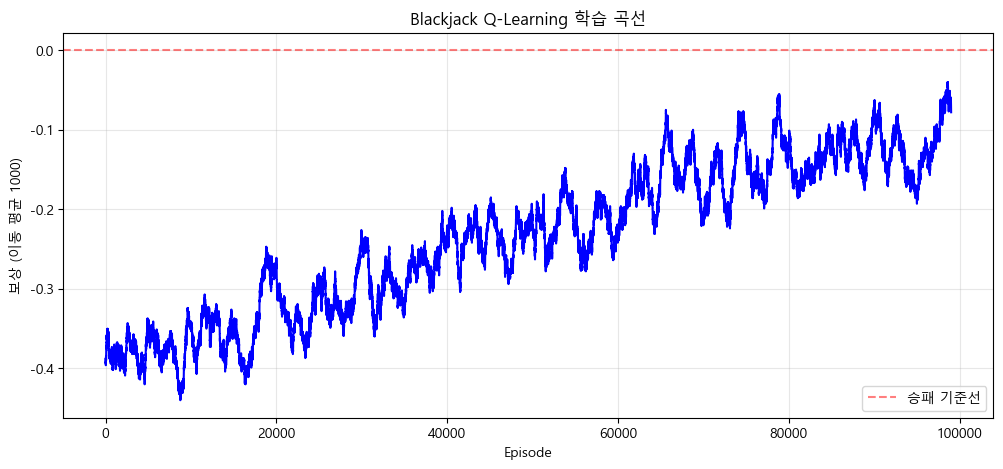

보상 의미: +1 = 승, -1 = 패, 0 = 무승부
블랙잭은 카지노 게임이라 평균이 0 이상이면 매우 잘하는 것!


In [9]:
# 이동 평균 (1000 에피소드 윈도우)
def moving_average(data, window=1000):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(moving_average(episode_rewards, window=1000), color='blue')  # window=1000
plt.xlabel('Episode')
plt.ylabel('보상 (이동 평균 1000)')
plt.title('Blackjack Q-Learning 학습 곡선')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='승패 기준선')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('보상 의미: +1 = 승, -1 = 패, 0 = 무승부')
print('블랙잭은 카지노 게임이라 평균이 0 이상이면 매우 잘하는 것!')

## 셀 8 — 승률 분석

학습된 에이전트로 10,000번 플레이하여 승률을 측정합니다.

In [10]:
# 승률 테스트
test_env = gym.make('Blackjack-v1', sab=True)

wins = 0
draws = 0
losses = 0
n_test = 10000

for _ in range(n_test):
    state, _ = test_env.reset()
    done = False

    while not done:
      # 최적 행동 선택 (활용)
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated

    if reward > 0:       # 승리
        wins += 1
    elif reward == 0:    # 무승부
        draws += 1
    else:                # 패배
        losses += 1

win_rate = wins / n_test * 100
draw_rate = draws / n_test * 100
loss_rate = losses / n_test * 100

print(f'=== 승률 분석 ({n_test:,}게임) ===')
print(f'승리: {wins:,} ({win_rate:.1f}%)')
print(f'무승부: {draws:,} ({draw_rate:.1f}%)')
print(f'패배: {losses:,} ({loss_rate:.1f}%)')
print(f'\n승률: {win_rate:.1f}%')
test_env.close()

=== 승률 분석 (10,000게임) ===
승리: 4,222 (42.2%)
무승부: 903 (9.0%)
패배: 4,875 (48.8%)

승률: 42.2%


## 셀 9 — 전략 시각화 (선택): 언제 hit, 언제 stick?

학습된 Q-Table에서 에이전트의 전략을 히트맵으로 시각화합니다.

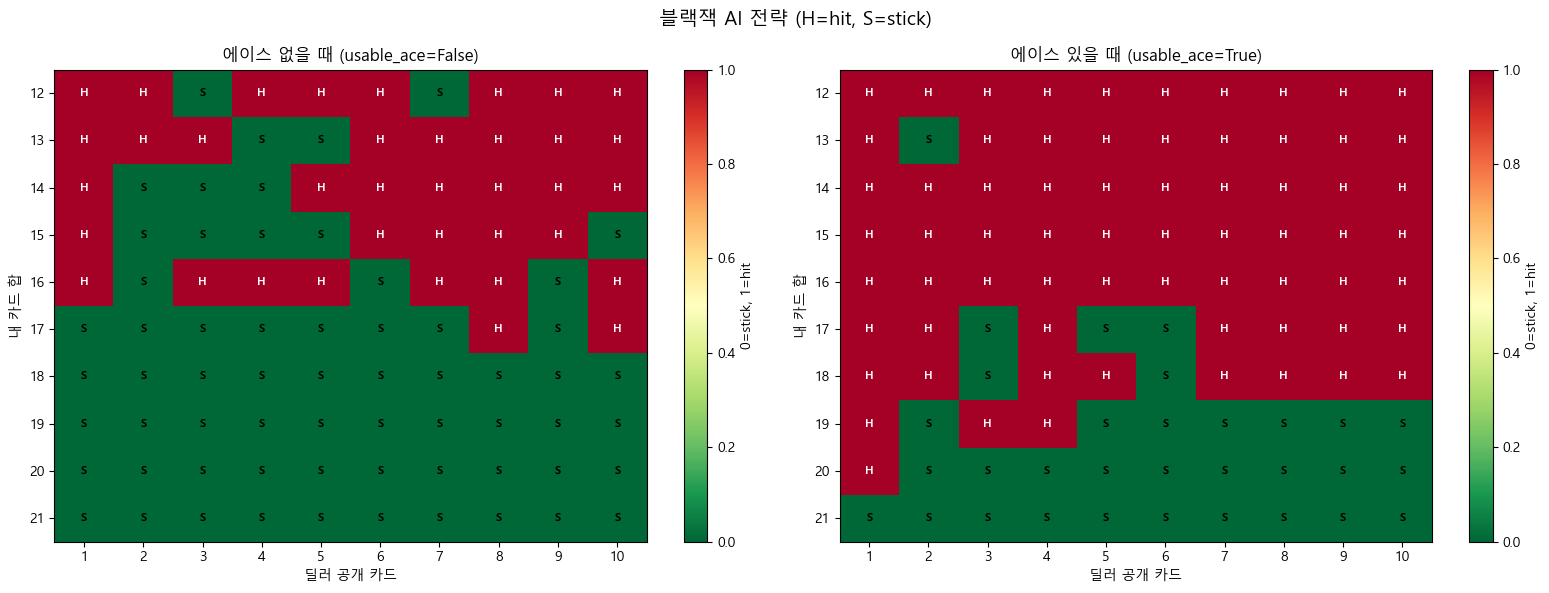

초록색(S): stick (멈추기) / 빨간색(H): hit (카드 더 받기)
카드 합이 높을수록 stick, 낮을수록 hit → 상식적인 전략!


In [11]:
def plot_strategy(q_table, usable_ace, title):
    """블랙잭 전략을 히트맵으로 시각화"""
    # 전략 맵: player_sum (12~21) x dealer_card (1~10)
    strategy = np.zeros((10, 10))  # 10x10 격자

    for player_sum in range(12, 22):       # 12~21
        for dealer_card in range(1, 11):    # 1~10
            state = (player_sum, dealer_card, usable_ace)
            # 0=stick, 1=hit
            action = np.argmax(q_table[state])
            strategy[player_sum - 12][dealer_card - 1] = action

    plt.imshow(strategy, cmap='RdYlGn_r', interpolation='nearest', aspect='auto')
    plt.xlabel('딜러 공개 카드')
    plt.ylabel('내 카드 합')
    plt.xticks(range(10), range(1, 11))
    plt.yticks(range(10), range(12, 22))
    plt.title(title)
    plt.colorbar(label='0=stick, 1=hit')

    # 각 셀에 텍스트 표시
    for i in range(10):
        for j in range(10):
            text = 'H' if strategy[i][j] == 1 else 'S'
            color = 'white' if strategy[i][j] == 1 else 'black'
            plt.text(j, i, text, ha='center', va='center', fontsize=8, color=color, fontweight='bold')


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.subplot(1, 2, 1)
plot_strategy(q_table, False, '에이스 없을 때 (usable_ace=False)')

plt.subplot(1, 2, 2)
plot_strategy(q_table, True, '에이스 있을 때 (usable_ace=True)')

plt.suptitle('블랙잭 AI 전략 (H=hit, S=stick)', fontsize=14)
plt.tight_layout()
plt.show()

print('초록색(S): stick (멈추기) / 빨간색(H): hit (카드 더 받기)')
print('카드 합이 높을수록 stick, 낮을수록 hit → 상식적인 전략!')

## ✅ 도장 획득 체크!

승률이 40% 이상이면 🥇 도장을 획득합니다!

In [12]:
# 도장 체크
if win_rate > 40.0:
    print("✅ 통과!")
else:
    print("⚠️ 아직 부족합니다. 에피소드를 늘리거나 하이퍼파라미터를 조정해보세요.")

print('=' * 50)
print('🥇 도장 3 획득! 블랙잭 AI 완성!')
print('=' * 50)
print()
print(f'승률: {win_rate:.1f}%')
print(f'학습된 상태 수: {len(q_table)}')
print()
print('핵심 배운 점:')
print('  1. 상태가 튜플이면 np.zeros 대신 defaultdict 사용!')
print('  2. 확률 게임은 더 많은 에피소드가 필요 (10만+)')
print('  3. 같은 Q-Learning 알고리즘이지만 자료구조 적응이 필요!')
print()
print('🎉 도장깨기 완료! 3개 도장 모두 획득!')
print('  🥉 Taxi — 코드 재사용')
print('  🥈 CliffWalking — 보상 설계')
print('  🥇 Blackjack — 자료구조 적응')

✅ 통과!
🥇 도장 3 획득! 블랙잭 AI 완성!

승률: 42.2%
학습된 상태 수: 280

핵심 배운 점:
  1. 상태가 튜플이면 np.zeros 대신 defaultdict 사용!
  2. 확률 게임은 더 많은 에피소드가 필요 (10만+)
  3. 같은 Q-Learning 알고리즘이지만 자료구조 적응이 필요!

🎉 도장깨기 완료! 3개 도장 모두 획득!
  🥉 Taxi — 코드 재사용
  🥈 CliffWalking — 보상 설계
  🥇 Blackjack — 자료구조 적응
